In [13]:
import os, glob, json, re
import pandas as pd

In [14]:
df = pd.read_csv('../data_listings/data-listings.csv', encoding='utf-8-sig')
df

,title,description,project_unit,project_name,area,floor_area,price,location,bedrooms,bathrooms,floor,condition,property_type,offer_type,construction_year,parking_spaces,ownership_type,project_link,publish_date,publish_by
0,3BR Condo Calinea Near SM Grand Central Monume...,Enjoy excellent accessibility by living in THE...,The Calinea Tower,The Calinea Tower,79 sqm,79 sqm,"₱ 11,742,000","Grace Park East, Caloocan",3 bedrooms,2 bathrooms,NaN,NaN,Condo,For Sale,NaN,NaN,NaN,https://www.lamudi.com.ph/projects/the-calinea...,3 Jul 2025,Corz Cascayan
1,2BR CondoNear SM grand Central Calinea DMCI Pr...,THE CALINEA TOWER by DMCI Homes\n\nM. H. Del P...,The Calinea Tower,The Calinea Tower,51 sqm,51 sqm,"₱ 9,100,000","Grace Park East, Caloocan",2 bedrooms,1 bathroom,NaN,NaN,Condo,For Sale,NaN,NaN,NaN,https://www.lamudi.com.ph/projects/the-calinea...,3 Jul 2025,Corz Cascayan
2,Calinea tower 126sqm 3BR DMCI newest Presellin...,Enjoys excellent accessibility by living in TH...,The Calinea Tower,The Calinea Tower,126 sqm,126 sqm,"₱ 22,000,000","Grace Park East, Caloocan",3 bedrooms,3 bathrooms,NaN,Unfurnished,Condo,For Sale,NaN,NaN,NaN,https://www.lamudi.com.ph/projects/the-calinea...,3 Jul 2025,Corz Cascayan
3,Spacious Studio Condo For Sale in Caloocan City,NaN,The Calinea Tower,The Calinea Tower,NaN,33 sqm,"₱ 6,346,000","Grace Park East, Caloocan",NaN,1 bathroom,NaN,Unfurnished,Condo,For Sale,NaN,NaN,Freehold,https://www.lamudi.com.ph/projects/the-calinea...,14 Jun 2025,"Michelle Madarang, REB"
4,FOR SALE: The Calinea Tower,NaN,The Calinea Tower,The Calinea Tower,NaN,86 sqm,"₱ 13,025,000","Grace Park East, Caloocan",3 bedrooms,2 bathrooms,NaN,Unfurnished,Condo,For Sale,NaN,NaN,NaN,https://www.lamudi.com.ph/projects/the-calinea...,13 Jun 2025,Condominium for Sale PH by Rey Ann Roguel
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15596,VICTORIA DE VALENZUELA Near Our Lady of Fatima...,Get a unit for as low as P8k a month!!!\nNewes...,NaN,NaN,NaN,22 sqm,"₱ 2,709,550","Valenzuela, Metro Manila",1 bedroom,1 bathroom,45,Unfurnished,Condo,For Sale,NaN,NaN,Freehold,NaN,2 May 2022,Calvin Reyes
15597,CONDO NEAR FATIMA UNIVERSITY AND MCU MEDICAL C...,Get a unit for as low as P8k a month!!!\nNewes...,NaN,NaN,NaN,22 sqm,"₱ 2,700,888","Valenzuela, Metro Manila",2 bedrooms,2 bathrooms,45,Unfurnished,Condo,For Sale,NaN,NaN,Freehold,NaN,2 May 2022,Calvin Reyes
15598,affordable condominium in valenzuela city near...,Victoria de Valenzuela“The Newest Sports Condo...,NaN,NaN,NaN,22 sqm,"₱ 2,750,002","Valenzuela, Metro Manila",1 bedroom,1 bathroom,45,Unfurnished,Condo,For Sale,NaN,NaN,Freehold,NaN,2 May 2022,Calvin Reyes
15599,condominium in valenzuela near fatima universi...,2.7m to 3m total price \n15k reservation fee\n...,NaN,NaN,NaN,22 sqm,"₱ 2,780,000","Valenzuela, Metro Manila",1 bedroom,1 bathroom,45,Unfurnished,Condo,For Sale,NaN,NaN,Freehold,NaN,2 May 2022,Calvin Reyes


In [15]:
# Drop 'publish_date'. Remove duplicates and reset index
df = df.drop(columns=['publish_date']).drop_duplicates().reset_index(drop=True)

# strip multiple spaces in 'title' and 'description' columns
df['title'] = df['title'].str.replace(r'\s{2,}', ' ', regex=True)
df['description'] = df['description'].str.replace(r'\s{2,}', ' ', regex=True)

In [16]:
df_projects = pd.read_csv('../data_properties/data-properties-with-corrections.csv', dtype=str, encoding='utf-8-sig')
df_projects

,project_name,location
0,100 West,"Pio Del Pilar, Makati, Metro Manila"
1,100 West Makati,"Pio Del Pilar, Makati, Metro Manila"
2,1001 Parkway Residences,"Muntinlupa, Metro Manila"
3,101 Newport BLVD,"Pasay, Metro Manila"
4,101 Xavierville,"Loyola Heights, Quezon City, Metro Manila"
...,...,...
1011,dakotaresidences,"Tugatog, Malabon, Metro Manila"
1012,mckinley hill garden villas,"Bagong Tanyag, Taguig, Metro Manila"
1013,oriental gardens makati,"Bangkal, Makati, Metro Manila"
1014,symfoni kamias,"Ramon Magsaysay, Quezon City, Metro Manila"


In [17]:
# from each row in df, if 'project_name' is empty, find the 1st matching 'project_name' in df_projects that is a substring of 'description' or 'title' and fill in 'project_name' from df_projects
for i, row in df.iterrows():
    if pd.isna(row['project_name']) or row['project_name'].strip() == '':
        for j, proj_row in df_projects.iterrows():
            if proj_row['project_name'].lower() in str(row['description']).lower():
                df.at[i, 'project_name'] = proj_row['project_name']
            else:
                if proj_row['project_name'].lower() in str(row['title']).lower():
                    df.at[i, 'project_name'] = proj_row['project_name']
                    break



In [18]:
df1 = df.copy()
df1.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
title,12107,10686,Bare 2BR Unit for Sale at Mi Casa Hawaii Tower...,65,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,8949,6758,READY FOR OCCUPANCY CONDO IN BAY AREA 2br pet ...,70,NaN,NaN,NaN,NaN,NaN,NaN,NaN
project_unit,6799,742,The Hermosa,283,NaN,NaN,NaN,NaN,NaN,NaN,NaN
project_name,10393,804,Palm Beach West,369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area,3018,324,21 sqm,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
floor_area,12083,409,23 sqm,446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,11529,3582,"₱ 4,500,000",163,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,12107,237,"Fort Bonifacio, Taguig",1070,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bedrooms,10350,21,1 bedroom,4443,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bathrooms,10854,21,1 bathroom,7118,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
# remove duplicate rows and filter out rows with missing 'project_name', 'price', 'floor_area', 'bedrooms', 'bathrooms', 'condition'
df1 = df1.drop_duplicates().dropna(subset=['project_name', 'price', 'floor_area', 'bedrooms', 'bathrooms', 'condition']).reset_index(drop=True)
df1.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
title,6775,5969,Bare 2BR Unit for Sale at Mi Casa Hawaii Tower...,65,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,5200,4019,READY FOR OCCUPANCY CONDO IN BAY AREA 2br pet ...,69,NaN,NaN,NaN,NaN,NaN,NaN,NaN
project_unit,4820,648,The Hermosa,131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
project_name,6775,705,Sonora Garden Residences,185,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area,2147,296,28 sqm,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN
floor_area,6775,345,38 sqm,226,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,6775,2444,"₱ 4,500,000",90,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,6775,195,"Fort Bonifacio, Taguig",712,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bedrooms,6775,10,1 bedroom,2999,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bathrooms,6775,14,1 bathroom,4301,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
# remove non-numeric characters from 'price', 'area', 'floor_area', 'bedrooms', 'bathrooms' columns and convert to numeric dtype
df1['price'] = pd.to_numeric(df1['price'].str.replace(r'[^\d.]*', '', regex=True), errors='coerce')
df1['area'] = pd.to_numeric(df1['area'].str.replace(r'[^\d.]*', '', regex=True), errors='coerce')
df1['floor_area'] = pd.to_numeric(df1['floor_area'].str.replace(r'[^\d.]*', '', regex=True), errors='coerce')
df1['bedrooms'] = pd.to_numeric(df1['bedrooms'].str.replace(r'[^\d.]*', '', regex=True), errors='coerce')
df1['bathrooms'] = pd.to_numeric(df1['bathrooms'].str.replace(r'[^\d.]*', '', regex=True), errors='coerce')

df1.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
title,6775,5969,Bare 2BR Unit for Sale at Mi Casa Hawaii Tower...,65,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,5200,4019,READY FOR OCCUPANCY CONDO IN BAY AREA 2br pet ...,69,NaN,NaN,NaN,NaN,NaN,NaN,NaN
project_unit,4820,648,The Hermosa,131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
project_name,6775,705,Sonora Garden Residences,185,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area,2147.0,NaN,NaN,NaN,147.804378,1499.40163,2.0,47.0,77.0,135.0,69000.0
floor_area,6775.0,NaN,NaN,NaN,10912.912915,652320.981309,1.0,33.0,54.0,90.0,52086697.0
price,6771.0,NaN,NaN,NaN,22045822.942549,37634328.938991,17.0,5400000.0,9500000.0,22900000.0,686000000.0
location,6775,195,"Fort Bonifacio, Taguig",712,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bedrooms,6775.0,NaN,NaN,NaN,1.773432,1.007883,1.0,1.0,2.0,2.0,41.0
bathrooms,6775.0,NaN,NaN,NaN,1.571956,1.057449,1.0,1.0,1.0,2.0,28.0


In [21]:
def find_with_parking(text):
    # Returns the matched string if found, else None
    match = re.search(r'with(\s+\w+)?\s+parking', str(text), re.IGNORECASE)
    if match:
        return match.group(0)
    return None

df1['parking_info'] = df1.apply(lambda row: find_with_parking(row['title']) or find_with_parking(row['description']), axis=1)

# get numeric parking count from parking_info if available, else set to 1 if parking_info is not null and 0 if parking_info is null
def extract_parking_count(parking_info):
    if pd.isna(parking_info):
        return 0
    match = re.search(r'(\d+)', parking_info)
    if match:
        return int(match.group(1))
    return 1

# get max between existing 'parking_spaces' column and extracted parking count from parking_info, add new column 'parking'
df1['parking'] = df1.apply(lambda row: max(row['parking_spaces'], extract_parking_count(row['parking_info'])) if not pd.isna(row['parking_spaces']) else extract_parking_count(row['parking_info']), axis=1)

# drop 'parking_spaces' and 'parking_info' columns
df1 = df1.drop(columns=['parking_spaces', 'parking_info'])

df1.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
title,6775,5969,Bare 2BR Unit for Sale at Mi Casa Hawaii Tower...,65,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,5200,4019,READY FOR OCCUPANCY CONDO IN BAY AREA 2br pet ...,69,NaN,NaN,NaN,NaN,NaN,NaN,NaN
project_unit,4820,648,The Hermosa,131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
project_name,6775,705,Sonora Garden Residences,185,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area,2147.0,NaN,NaN,NaN,147.804378,1499.40163,2.0,47.0,77.0,135.0,69000.0
floor_area,6775.0,NaN,NaN,NaN,10912.912915,652320.981309,1.0,33.0,54.0,90.0,52086697.0
price,6771.0,NaN,NaN,NaN,22045822.942549,37634328.938991,17.0,5400000.0,9500000.0,22900000.0,686000000.0
location,6775,195,"Fort Bonifacio, Taguig",712,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bedrooms,6775.0,NaN,NaN,NaN,1.773432,1.007883,1.0,1.0,2.0,2.0,41.0
bathrooms,6775.0,NaN,NaN,NaN,1.571956,1.057449,1.0,1.0,1.0,2.0,28.0


In [22]:
# Filter property_type to exclude "Condotel"
df1 = df1[df1['property_type'] != "Condotel"]

# Filter rows based on column: 'offer_type'
df1 = df1[df1['offer_type'] == "For Sale"]

df1.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
title,6689,5885,Bare 2BR Unit for Sale at Mi Casa Hawaii Tower...,65,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,5115,3942,READY FOR OCCUPANCY CONDO IN BAY AREA 2br pet ...,69,NaN,NaN,NaN,NaN,NaN,NaN,NaN
project_unit,4751,643,The Hermosa,131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
project_name,6689,701,Sonora Garden Residences,185,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area,2121.0,NaN,NaN,NaN,148.027346,1508.525107,2.0,47.0,77.0,134.0,69000.0
floor_area,6689.0,NaN,NaN,NaN,11052.255793,656500.468813,1.0,33.0,54.0,90.0,52086697.0
price,6689.0,NaN,NaN,NaN,22070647.393033,37719850.864597,17.0,5400000.0,9500000.0,22999999.0,686000000.0
location,6689,195,"Fort Bonifacio, Taguig",703,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bedrooms,6689.0,NaN,NaN,NaN,1.771416,1.009042,1.0,1.0,2.0,2.0,41.0
bathrooms,6689.0,NaN,NaN,NaN,1.570788,1.057889,1.0,1.0,1.0,2.0,28.0


In [23]:
# drop unnecessary columns
df1 = df1.drop(columns=['title', 'description', 'project_unit', 'location', 'area', 'floor', 'property_type', 'offer_type', 'construction_year', 'ownership_type', 'project_link', 'publish_by'])

# remove duplicate rows
df1.drop_duplicates()

df1.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
project_name,6689,701,Sonora Garden Residences,185,NaN,NaN,NaN,NaN,NaN,NaN,NaN
floor_area,6689.0,NaN,NaN,NaN,11052.255793,656500.468813,1.0,33.0,54.0,90.0,52086697.0
price,6689.0,NaN,NaN,NaN,22070647.393033,37719850.864597,17.0,5400000.0,9500000.0,22999999.0,686000000.0
bedrooms,6689.0,NaN,NaN,NaN,1.771416,1.009042,1.0,1.0,2.0,2.0,41.0
bathrooms,6689.0,NaN,NaN,NaN,1.570788,1.057889,1.0,1.0,1.0,2.0,28.0
condition,6689,3,Unfurnished,2909,NaN,NaN,NaN,NaN,NaN,NaN,NaN
parking,6689.0,NaN,NaN,NaN,0.370758,0.719321,0.0,0.0,0.0,1.0,6.0


In [24]:
df1

,project_name,floor_area,price,bedrooms,bathrooms,condition,parking
0,The Calinea Tower,126,22000000.0,3,3,Unfurnished,0.0
1,The Calinea Tower,86,13025000.0,3,2,Unfurnished,0.0
2,The Calinea Tower,30,6007000.0,1,1,Unfurnished,0.0
3,The Calinea Tower,70,10938000.0,2,1,Unfurnished,0.0
4,The Calinea Tower,79,11700000.0,3,2,Unfurnished,0.0
...,...,...,...,...,...,...,...
6770,Isabelle de Valenzuela,42,5000000.0,2,1,Unfurnished,0.0
6771,Isabelle de Valenzuela,42,2100000.0,3,1,Unfurnished,0.0
6772,Alta Spatial,33,4999100.0,2,1,Partly furnished,0.0
6773,Alta Spatial,33,4051961.0,2,1,Unfurnished,0.0


In [25]:
# drop rows with floor_area less than 10 or greater than 1000 or price less than 1000000
df1 = df1[(df1['floor_area'] >= 10) & (df1['floor_area'] <= 1000) & (df1['price'] >= 1000000)]
df1.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
project_name,6374,696,Sonora Garden Residences,183,NaN,NaN,NaN,NaN,NaN,NaN,NaN
floor_area,6374.0,NaN,NaN,NaN,80.796988,77.27075,12.0,34.0,56.0,94.0,904.0
price,6374.0,NaN,NaN,NaN,23012350.029495,37515434.139859,1000000.0,5804591.0,10000000.0,23787500.0,686000000.0
bedrooms,6374.0,NaN,NaN,NaN,1.79134,0.951061,1.0,1.0,2.0,2.0,41.0
bathrooms,6374.0,NaN,NaN,NaN,1.592093,1.075193,1.0,1.0,1.0,2.0,28.0
condition,6374,3,Unfurnished,2843,NaN,NaN,NaN,NaN,NaN,NaN,NaN
parking,6374.0,NaN,NaN,NaN,0.387355,0.728542,0.0,0.0,0.0,1.0,5.0


In [26]:
# add 'price_per_sqm' column
df1['price_per_sqm'] = df1['price'] / df1['floor_area']
df1.describe(include='all').T

/var/folders/kc/m48gl72d5k9c9xrv2cwrmz_h0000gn/T/ipykernel_34624/1641590057.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['price_per_sqm'] = df1['price'] / df1['floor_area']


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
project_name,6374,696,Sonora Garden Residences,183,NaN,NaN,NaN,NaN,NaN,NaN,NaN
floor_area,6374.0,NaN,NaN,NaN,80.796988,77.27075,12.0,34.0,56.0,94.0,904.0
price,6374.0,NaN,NaN,NaN,23012350.029495,37515434.139859,1000000.0,5804591.0,10000000.0,23787500.0,686000000.0
bedrooms,6374.0,NaN,NaN,NaN,1.79134,0.951061,1.0,1.0,2.0,2.0,41.0
bathrooms,6374.0,NaN,NaN,NaN,1.592093,1.075193,1.0,1.0,1.0,2.0,28.0
condition,6374,3,Unfurnished,2843,NaN,NaN,NaN,NaN,NaN,NaN,NaN
parking,6374.0,NaN,NaN,NaN,0.387355,0.728542,0.0,0.0,0.0,1.0,5.0
price_per_sqm,6374.0,NaN,NaN,NaN,230062.34353,128127.174584,19157.088123,148476.475279,204545.454545,294215.252473,3058181.818182


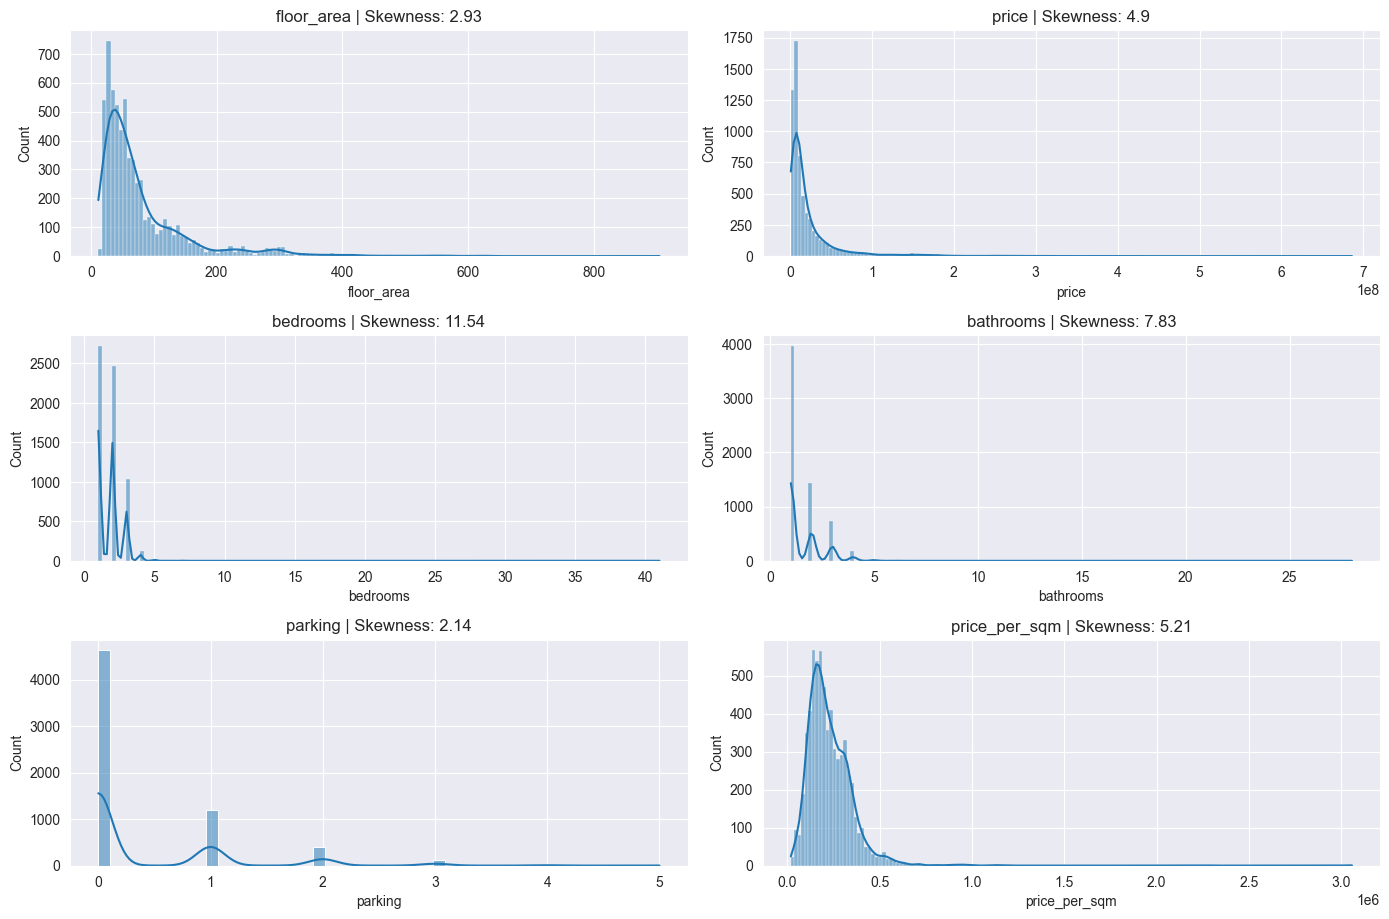

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("darkgrid")

numerical_columns = df1.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(14, len(numerical_columns) * 3))
for idx, feature in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 2, idx)
    sns.histplot(df1[feature], kde=True)
    plt.title(f"{feature} | Skewness: {round(df1[feature].skew(), 2)}")

plt.tight_layout()
plt.show()

In [28]:
# Use IQR to identify outliers for 'floor_area', 'price', 'price_per_sqm'
def iqr_outlier_mask(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return (df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)

outlier_mask = (
    iqr_outlier_mask(df1, 'floor_area') |
    iqr_outlier_mask(df1, 'price') |
    iqr_outlier_mask(df1, 'price_per_sqm') |
    iqr_outlier_mask(df1, 'bedrooms') |
    iqr_outlier_mask(df1, 'bathrooms') |
    iqr_outlier_mask(df1, 'parking')
)

outliers_df2 = df1[outlier_mask]
df2 = df1[~outlier_mask].reset_index(drop=True)

In [29]:
outliers_df2.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
project_name,784,159,Aurelia Residences,59,NaN,NaN,NaN,NaN,NaN,NaN,NaN
floor_area,784.0,NaN,NaN,NaN,241.260204,105.797289,28.0,162.0,225.0,291.0,904.0
price,784.0,NaN,NaN,NaN,95787950.218112,67820109.610501,4180008.0,55305053.25,75000000.0,124250000.0,686000000.0
bedrooms,784.0,NaN,NaN,NaN,3.084184,1.548882,1.0,3.0,3.0,3.0,41.0
bathrooms,784.0,NaN,NaN,NaN,3.269133,1.91859,1.0,3.0,3.0,4.0,28.0
condition,784,3,Unfurnished,264,NaN,NaN,NaN,NaN,NaN,NaN,NaN
parking,784.0,NaN,NaN,NaN,1.415816,1.203679,0.0,0.0,2.0,2.0,5.0
price_per_sqm,784.0,NaN,NaN,NaN,398623.155778,227040.513823,19157.088123,301925.311536,376569.554422,473794.76119,3058181.818182


In [30]:
df2

,project_name,floor_area,price,bedrooms,bathrooms,condition,parking,price_per_sqm
0,The Calinea Tower,126,22000000.0,3,3,Unfurnished,0.0,174603.174603
1,The Calinea Tower,86,13025000.0,3,2,Unfurnished,0.0,151453.488372
2,The Calinea Tower,30,6007000.0,1,1,Unfurnished,0.0,200233.333333
3,The Calinea Tower,70,10938000.0,2,1,Unfurnished,0.0,156257.142857
4,The Calinea Tower,79,11700000.0,3,2,Unfurnished,0.0,148101.265823
...,...,...,...,...,...,...,...,...
5585,Isabelle de Valenzuela,42,5000000.0,2,1,Unfurnished,0.0,119047.619048
5586,Isabelle de Valenzuela,42,2100000.0,3,1,Unfurnished,0.0,50000.000000
5587,Alta Spatial,33,4999100.0,2,1,Partly furnished,0.0,151487.878788
5588,Alta Spatial,33,4051961.0,2,1,Unfurnished,0.0,122786.696970


In [31]:
df2.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
project_name,5590,653,Sonora Garden Residences,180,NaN,NaN,NaN,NaN,NaN,NaN,NaN
floor_area,5590.0,NaN,NaN,NaN,58.29195,33.492784,12.0,33.0,50.0,73.0,180.0
price,5590.0,NaN,NaN,NaN,12805539.555814,10644791.491928,1000000.0,5500000.0,8500000.0,16900000.0,50493000.0
bedrooms,5590.0,NaN,NaN,NaN,1.610018,0.654182,1.0,1.0,2.0,2.0,3.0
bathrooms,5590.0,NaN,NaN,NaN,1.356887,0.593851,1.0,1.0,1.0,2.0,3.0
condition,5590,3,Unfurnished,2579,NaN,NaN,NaN,NaN,NaN,NaN,NaN
parking,5590.0,NaN,NaN,NaN,0.243113,0.48277,0.0,0.0,0.0,0.0,2.0
price_per_sqm,5590.0,NaN,NaN,NaN,206421.614227,83385.86928,23641.975309,143687.5,193750.0,264361.995315,507692.307692


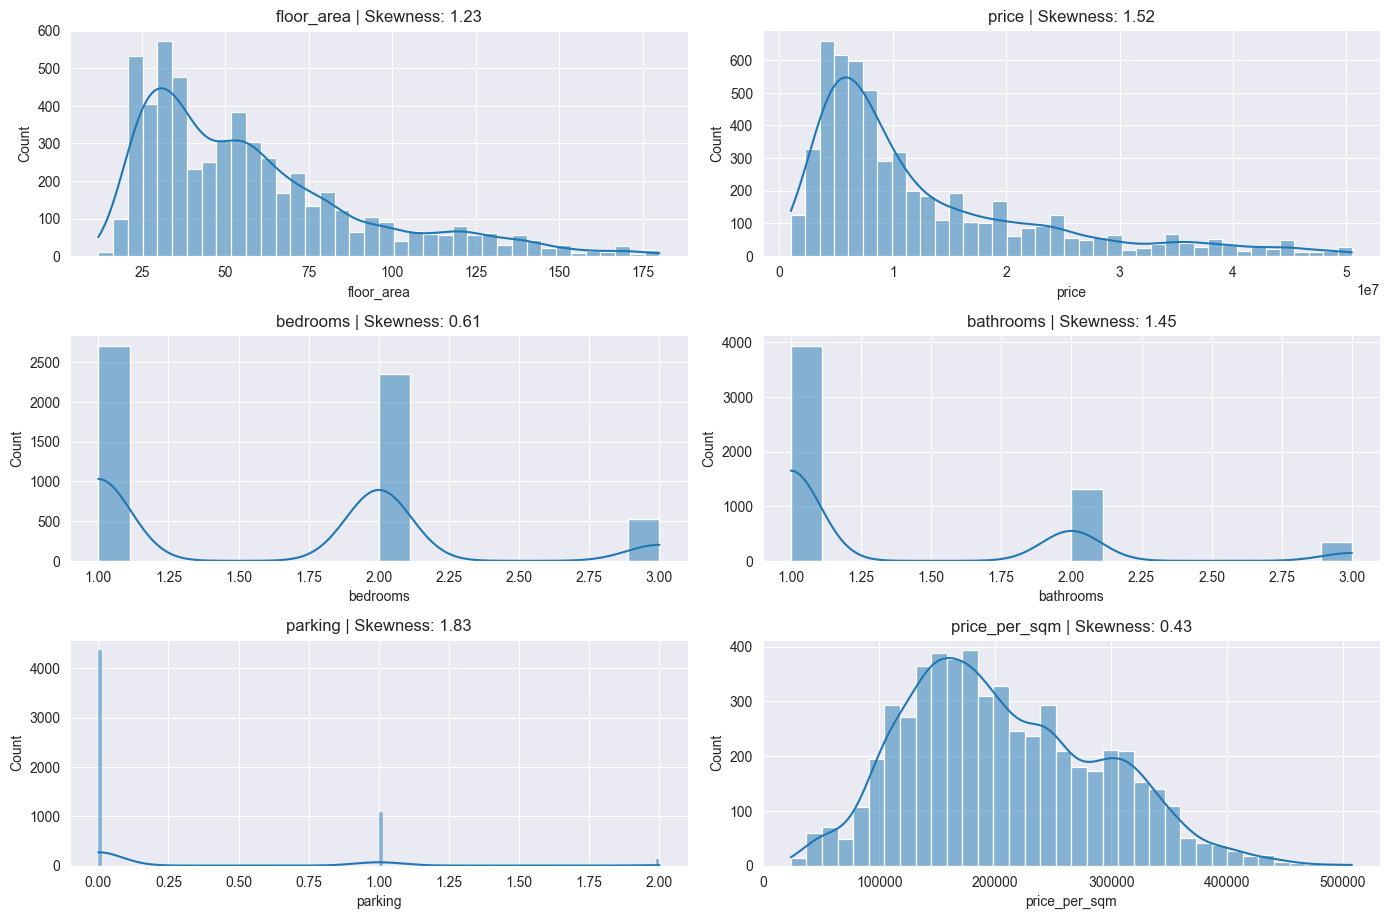

In [32]:
numerical_columns = df2.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(14, len(numerical_columns) * 3))
for idx, feature in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 2, idx)
    sns.histplot(df2[feature], kde=True)
    plt.title(f"{feature} | Skewness: {round(df2[feature].skew(), 2)}")

plt.tight_layout()
plt.show()

In [33]:
def sd_outlier_mask(df, col):
    mean = df[col].mean()
    std = df[col].std()
    return (df[col] < mean - 3 * std) | (df[col] > mean + 3 * std)

outlier_mask = (
    sd_outlier_mask(df1, 'floor_area') |
    sd_outlier_mask(df1, 'price') |
    sd_outlier_mask(df1, 'price_per_sqm') |
    sd_outlier_mask(df1, 'bedrooms') |
    sd_outlier_mask(df1, 'bathrooms') |
    sd_outlier_mask(df1, 'parking')
)

outliers_df3 = df1[outlier_mask]
df3 = df1[~outlier_mask].reset_index(drop=True)

In [34]:
outliers_df3.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
project_name,290,85,Aurelia Residences,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
floor_area,290.0,NaN,NaN,NaN,317.689655,127.645921,28.0,277.25,304.0,369.75,904.0
price,290.0,NaN,NaN,NaN,144503036.806897,86159956.622008,4180008.0,87000000.0,149000000.0,178000000.0,686000000.0
bedrooms,290.0,NaN,NaN,NaN,3.455172,2.392258,1.0,3.0,3.0,4.0,41.0
bathrooms,290.0,NaN,NaN,NaN,3.865517,2.903139,1.0,3.0,3.0,4.0,28.0
condition,290,3,Unfurnished,103,NaN,NaN,NaN,NaN,NaN,NaN,NaN
parking,290.0,NaN,NaN,NaN,1.975862,1.429824,0.0,0.0,2.0,3.0,5.0
price_per_sqm,290.0,NaN,NaN,NaN,487650.237142,322256.810974,20387.168142,320837.698886,455307.017544,576174.521761,3058181.818182


In [35]:
df3

,project_name,floor_area,price,bedrooms,bathrooms,condition,parking,price_per_sqm
0,The Calinea Tower,126,22000000.0,3,3,Unfurnished,0.0,174603.174603
1,The Calinea Tower,86,13025000.0,3,2,Unfurnished,0.0,151453.488372
2,The Calinea Tower,30,6007000.0,1,1,Unfurnished,0.0,200233.333333
3,The Calinea Tower,70,10938000.0,2,1,Unfurnished,0.0,156257.142857
4,The Calinea Tower,79,11700000.0,3,2,Unfurnished,0.0,148101.265823
...,...,...,...,...,...,...,...,...
6079,Isabelle de Valenzuela,42,5000000.0,2,1,Unfurnished,0.0,119047.619048
6080,Isabelle de Valenzuela,42,2100000.0,3,1,Unfurnished,0.0,50000.000000
6081,Alta Spatial,33,4999100.0,2,1,Partly furnished,0.0,151487.878788
6082,Alta Spatial,33,4051961.0,2,1,Unfurnished,0.0,122786.696970


In [36]:
df3.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
project_name,6084,679,Sonora Garden Residences,181,NaN,NaN,NaN,NaN,NaN,NaN,NaN
floor_area,6084.0,NaN,NaN,NaN,69.50526,51.753575,12.0,33.0,54.0,83.25,309.0
price,6084.0,NaN,NaN,NaN,17221373.835306,19611472.564219,1000000.0,5600000.0,9500000.0,20899000.0,135000000.0
bedrooms,6084.0,NaN,NaN,NaN,1.712032,0.733129,1.0,1.0,2.0,2.0,4.0
bathrooms,6084.0,NaN,NaN,NaN,1.483728,0.743362,1.0,1.0,1.0,2.0,4.0
condition,6084,3,Unfurnished,2740,NaN,NaN,NaN,NaN,NaN,NaN,NaN
parking,6084.0,NaN,NaN,NaN,0.311637,0.57699,0.0,0.0,0.0,1.0,2.0
price_per_sqm,6084.0,NaN,NaN,NaN,217784.156622,94611.693297,19157.088123,147207.891667,201801.948052,283783.783784,612903.225806


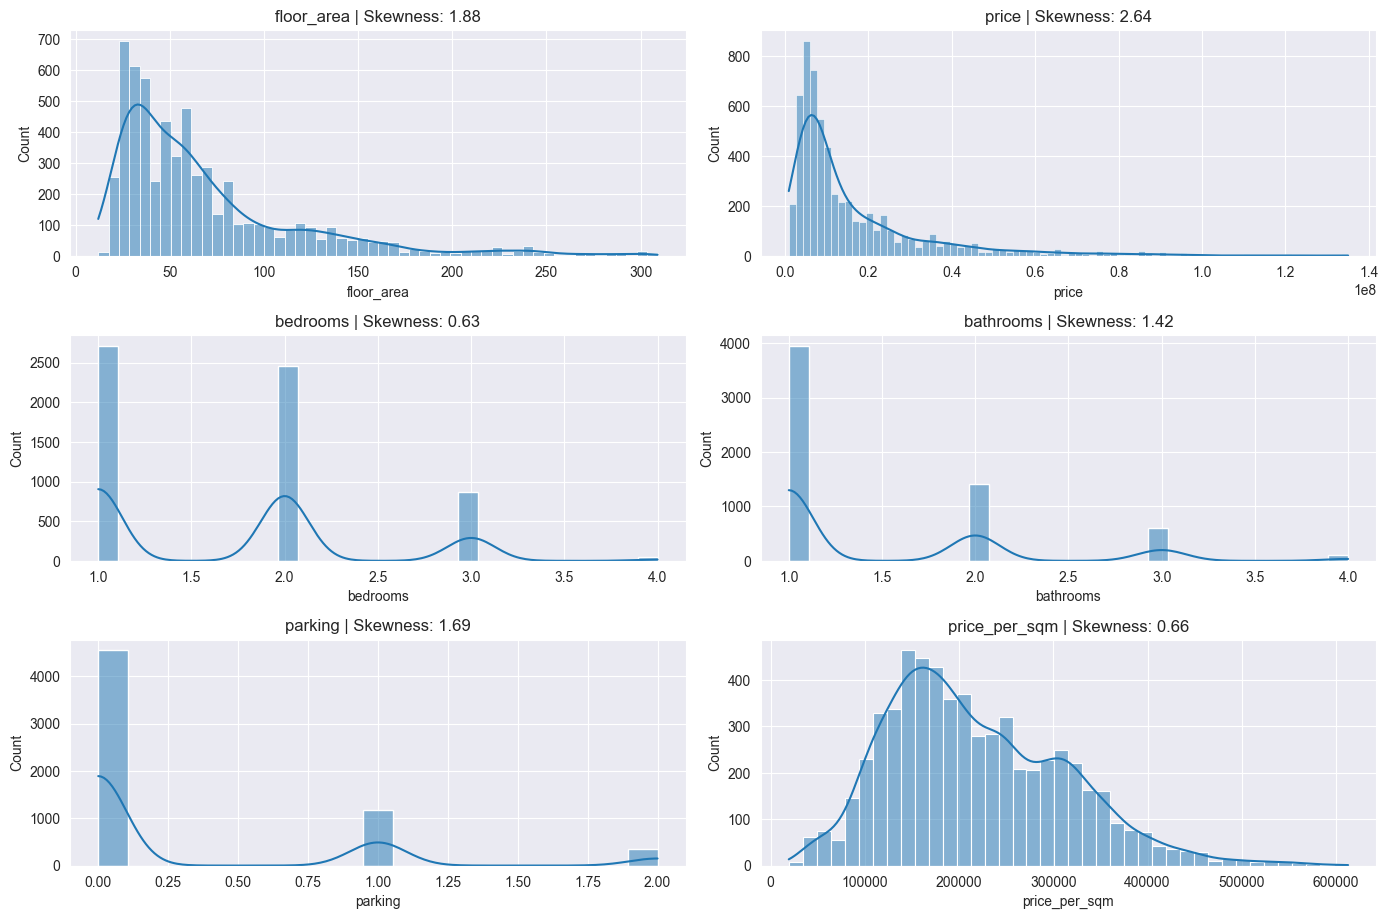

In [37]:
numerical_columns = df3.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(14, len(numerical_columns) * 3))
for idx, feature in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 2, idx)
    sns.histplot(df3[feature], kde=True)
    plt.title(f"{feature} | Skewness: {round(df3[feature].skew(), 2)}")

plt.tight_layout()
plt.show()

In [ ]:
df3.to_csv('../initial_poc/listings-cleaned.csv', index=False, encoding='utf-8-sig') 